# Análisis exploratorio de los datos

Este notebook lee el conjunto generado en la recopilación, realiza el análisis exploratorio y guarda una copia con las variables numéricas convertidas.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path


def localizar_raiz_proyecto():
    """Localiza la carpeta principal tanto desde VS Code como desde Jupyter."""
    carpeta_actual = Path.cwd().resolve()

    if (carpeta_actual / "datos").exists():
        return carpeta_actual

    if (carpeta_actual.parent / "datos").exists():
        return carpeta_actual.parent

    raise FileNotFoundError(
        "No se encuentra la carpeta 'datos'. Abre el notebook desde el repositorio."
    )


RAIZ_PROYECTO = localizar_raiz_proyecto()

RUTA_ENTRADA = RAIZ_PROYECTO / "datos" / "intermedios" / "dataset_recopilado.csv"
RUTA_SALIDA = RAIZ_PROYECTO / "datos" / "intermedios" / "dataset_eda.csv"

RUTA_SALIDA.parent.mkdir(parents=True, exist_ok=True)

In [2]:
# Lectura del resultado del notebook anterior
df_eda = pd.read_csv(RUTA_ENTRADA, dtype={"id": "string"})

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

variables_numericas = [
    "edad", "TSH", "T3", "TT4", "T4U", "FTI", "TBG"
]

# Conversión de las columnas numéricas
df_eda[variables_numericas] = df_eda[variables_numericas].apply(
    pd.to_numeric,
    errors="coerce"
)

print("Conjunto leído desde:", RUTA_ENTRADA)

Conjunto leído desde: C:\Users\frana\Desktop\codigo\prediccion-enfermedades-tiroideas\datos\intermedios\dataset_recopilado.csv


### Dimensiones y estructura del conjunto de datos

In [3]:
print("Número de registros:", df_eda.shape[0])
print("Número de columnas:", df_eda.shape[1])

display(df_eda.head())

df_eda.info()

Número de registros: 9172
Número de columnas: 32


,edad,sexo,tratamiento_con_tiroxina,consulta_sobre_tiroxina,medicacion_antitiroidea,enfermo,embarazada,cirugia_tiroidea,tratamiento_I131,consulta_hipotiroidismo,consulta_hipertiroidismo,litio,bocio,tumor,hipopituitarismo,trastorno_psiquiatrico,TSH_medida,TSH,T3_medida,T3,TT4_medida,TT4,T4U_medida,T4U,FTI_medido,FTI,TBG_medida,TBG,fuente,diagnostico,id,clase
0,29,F,f,f,f,f,f,f,f,t,f,f,f,f,f,f,t,0.3,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,other,-,840801013,otro
1,29,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,1.6,t,1.9,t,128.0,f,NaN,f,NaN,f,NaN,other,-,840801014,otro
2,41,F,f,f,f,f,f,f,f,f,t,f,f,f,f,f,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,t,11.0,other,-,840801042,otro
3,36,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,t,26.0,other,-,840803046,otro
4,32,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,t,36.0,other,S,840803047,otro


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9172 entries, 0 to 9171
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   edad                      9172 non-null   int64  
 1   sexo                      8865 non-null   object 
 2   tratamiento_con_tiroxina  9172 non-null   object 
 3   consulta_sobre_tiroxina   9172 non-null   object 
 4   medicacion_antitiroidea   9172 non-null   object 
 5   enfermo                   9172 non-null   object 
 6   embarazada                9172 non-null   object 
 7   cirugia_tiroidea          9172 non-null   object 
 8   tratamiento_I131          9172 non-null   object 
 9   consulta_hipotiroidismo   9172 non-null   object 
 10  consulta_hipertiroidismo  9172 non-null   object 
 11  litio                     9172 non-null   object 
 12  bocio                     9172 non-null   object 
 13  tumor                     9172 non-null   object 
 14  hipopitu

In [4]:
display(df_eda.describe(include="object").T)

,count,unique,top,freq
sexo,8865,2,F,6073
tratamiento_con_tiroxina,9172,2,f,7932
consulta_sobre_tiroxina,9172,2,f,9019
medicacion_antitiroidea,9172,2,f,9056
enfermo,9172,2,f,8828
embarazada,9172,2,f,9065
cirugia_tiroidea,9172,2,f,9038
tratamiento_I131,9172,2,f,9003
consulta_hipotiroidismo,9172,2,f,8542
consulta_hipertiroidismo,9172,2,f,8521


### Distribución de clases

In [5]:
conteo_clases = df_eda["clase"].value_counts()

tabla_clases = pd.DataFrame({
    "cantidad": conteo_clases,
    "porcentaje": (
        df_eda["clase"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

display(tabla_clases)

,cantidad,porcentaje
clase,,
otro,8285,90.33
hipotiroidismo,659,7.18
hipertiroidismo,228,2.49


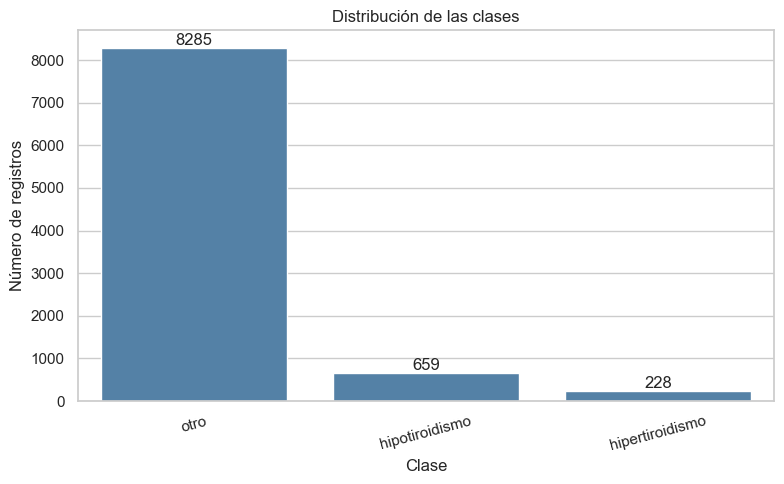

In [8]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df_eda,
    x="clase",
    color="steelblue"
)

ax.bar_label(ax.containers[0])

plt.title("Distribución de las clases")
plt.xlabel("Clase")
plt.ylabel("Número de registros")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Análisis de valores ausentes

In [6]:
tabla_nulos = pd.DataFrame({
    "cantidad": df_eda.isna().sum(),
    "porcentaje": df_eda.isna().mean().mul(100).round(2)
})

tabla_nulos = tabla_nulos[
    tabla_nulos["cantidad"] > 0
].sort_values("porcentaje", ascending=False)

display(tabla_nulos)

,cantidad,porcentaje
TBG,8823,96.19
T3,2604,28.39
TSH,842,9.18
T4U,809,8.82
FTI,802,8.74
TT4,442,4.82
sexo,307,3.35


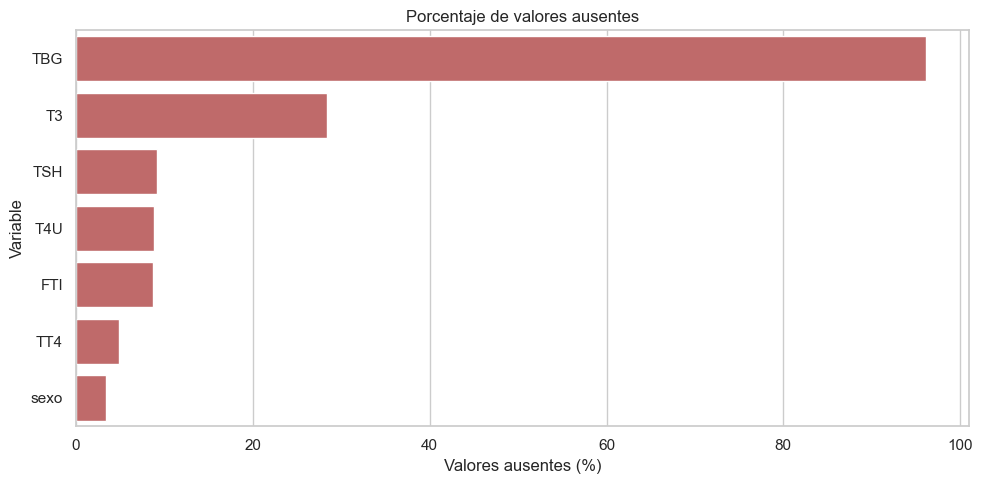

In [7]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=tabla_nulos,
    x="porcentaje",
    y=tabla_nulos.index,
    color="indianred"
)

plt.title("Porcentaje de valores ausentes")
plt.xlabel("Valores ausentes (%)")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### Análisis de las variables numéricas

In [9]:
display(df_eda[variables_numericas].describe().T)

,count,mean,std,min,25%,50%,75%,max
edad,9172.0,73.555822,1183.976718,1.000,37.00,55.00,68.000,65526.00
TSH,8330.0,5.218403,24.184006,0.005,0.46,1.40,2.700,530.00
T3,6568.0,1.970629,0.887579,0.050,1.50,1.90,2.300,18.00
TT4,8730.0,108.700305,37.522670,2.000,87.00,104.00,126.000,600.00
T4U,8363.0,0.976056,0.200360,0.170,0.86,0.96,1.065,2.33
FTI,8370.0,113.640746,41.551650,1.400,93.00,109.00,128.000,881.00
TBG,349.0,29.870057,21.080504,0.100,21.00,26.00,31.000,200.00


### Análisis de variables categóricas y binarias

In [11]:
variables_binarias = [
    "tratamiento_con_tiroxina",
    "consulta_sobre_tiroxina",
    "medicacion_antitiroidea",
    "enfermo",
    "embarazada",
    "cirugia_tiroidea",
    "tratamiento_I131",
    "consulta_hipotiroidismo",
    "consulta_hipertiroidismo",
    "litio",
    "bocio",
    "tumor",
    "hipopituitarismo",
    "trastorno_psiquiatrico"
]

porcentajes_verdaderos = {}

for variable in variables_binarias:
    valores_validos = df_eda[variable].notna().sum()
    cantidad_verdaderos = df_eda[variable].eq("t").sum()

    porcentajes_verdaderos[variable] = (
        cantidad_verdaderos / valores_validos * 100
    )

tabla_binarias = pd.Series(
    porcentajes_verdaderos,
    name="porcentaje_verdadero"
).sort_values(ascending=False)

display(tabla_binarias.round(2).to_frame())

,porcentaje_verdadero
tratamiento_con_tiroxina,13.52
consulta_hipertiroidismo,7.10
consulta_hipotiroidismo,6.87
trastorno_psiquiatrico,4.56
enfermo,3.75
tumor,2.63
tratamiento_I131,1.84
consulta_sobre_tiroxina,1.67
cirugia_tiroidea,1.46
medicacion_antitiroidea,1.26


In [13]:
print("Distribución del sexo:")
display(df_eda["sexo"].value_counts(dropna=False).to_frame())

print("Distribución de la fuente:")
display(df_eda["fuente"].value_counts(dropna=False).to_frame())

Distribución del sexo:


,count
sexo,
F,6073
M,2792
NaN,307


Distribución de la fuente:


,count
fuente,
other,5493
SVI,2394
SVHC,956
STMW,255
SVHD,71
WEST,3


### Relación entre las variables hormonales y la clase

In [14]:
variables_hormonales = [
    "TSH", "T3", "TT4", "T4U", "FTI"
]

medianas_por_clase = df_eda.groupby(
    "clase"
)[variables_hormonales].median()

display(medianas_por_clase)

,TSH,T3,TT4,T4U,FTI
clase,,,,,
hipertiroidismo,0.055,3.7,182.5,0.91,200.0
hipotiroidismo,14.000,1.5,76.0,0.99,78.0
otro,1.300,1.9,105.0,0.96,110.0


### Correlaciones

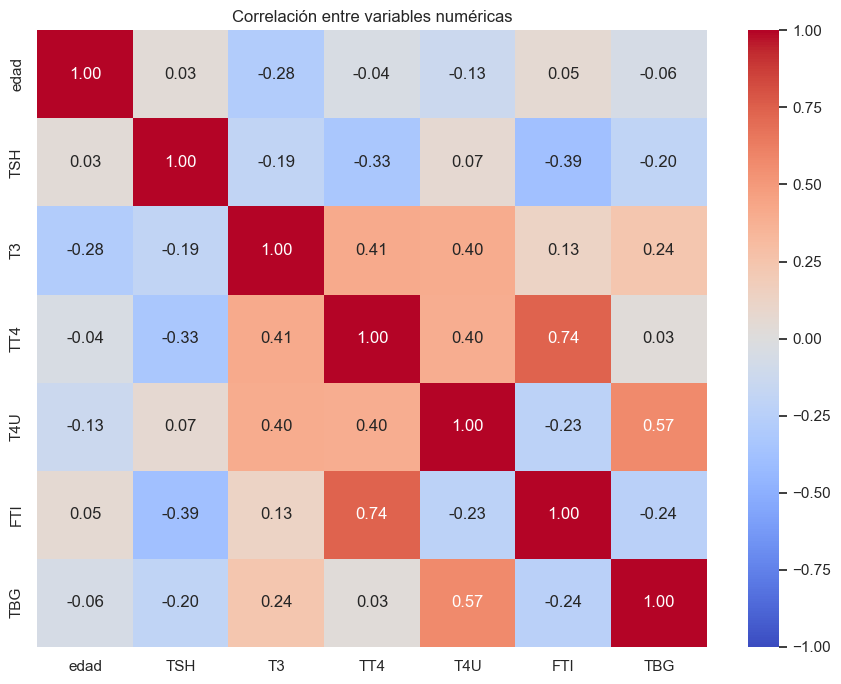

In [16]:
correlacion = df_eda[
    variables_numericas
].corr(method="spearman")

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Correlación entre variables numéricas")
plt.tight_layout()
plt.show()

### Comprobaciones sencillas de calidad

In [17]:
print("Filas duplicadas:", df_eda.duplicated().sum())
print("Identificadores duplicados:", df_eda["id"].duplicated().sum())

# Edades que no se consideran posibles
edades_incorrectas = df_eda[
    (df_eda["edad"] < 0) |
    (df_eda["edad"] > 110)
]

display(
    edades_incorrectas[
        ["edad", "diagnostico", "clase", "id"]
    ]
)

Filas duplicadas: 0
Identificadores duplicados: 0


,edad,diagnostico,clase,id
2976,455,-,otro,850530001
5710,65511,-,otro,860210008
6392,65512,-,otro,860403050
8105,65526,-,otro,861014041


## Guardado del conjunto analizado

In [18]:
# Esta copia será la entrada del notebook de preprocesamiento
df_eda.to_csv(RUTA_SALIDA, index=False)

print("Conjunto del EDA guardado en:")
print(RUTA_SALIDA)


Conjunto del EDA guardado en:
C:\Users\frana\Desktop\codigo\prediccion-enfermedades-tiroideas\datos\intermedios\dataset_eda.csv
